In [40]:
import pandas as pd

In [41]:
df= pd.read_csv("./datasets/train.csv", usecols= ['Age', 'Pclass', 'SibSp', 'Parch', 'Survived'])

In [42]:
df.head()

,Survived,Pclass,Age,SibSp,Parch
0,0,3,22.0,1,0
1,1,1,38.0,1,0
2,1,3,26.0,0,0
3,1,1,35.0,1,0
4,0,3,35.0,0,0


# Feature Construction
    - Feature construction is a part of feature engineering where we create new columns from the existing columns.
    - It is done manually and totally depends on the dataset

In [43]:
# making new feature i.e Family Size by joing SibSp and Parch
df['Family Size']= df['SibSp'] + df['Parch']

In [44]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Family Size
0,0,3,22.0,1,0,1
1,1,1,38.0,1,0,1
2,1,3,26.0,0,0,0
3,1,1,35.0,1,0,1
4,0,3,35.0,0,0,0


In [45]:
df.drop(columns= ['SibSp', 'Parch'], inplace= True)

In [46]:
df.sample(5)

,Survived,Pclass,Age,Family Size
317,0,2,54.0,0
39,1,3,14.0,1
566,0,3,19.0,0
482,0,3,50.0,0
345,1,2,24.0,0


In [47]:
def family(num):
    if num == 0:
        return 0  #small
    elif num>0 and num<= 3:
        return 1  #medium
    else:
        return 2  #large

In [48]:
## we can also change a value of a column by using a function

df['Family Size']= df['Family Size'].apply(func= family)

In [49]:
df.head()

,Survived,Pclass,Age,Family Size
0,0,3,22.0,1
1,1,1,38.0,1
2,1,3,26.0,0
3,1,1,35.0,1
4,0,3,35.0,0


Hence In this way we can do feature construction

## Feature Splitting
    - Feature Splitting is a part of feature construction where we split a feature into two or more columns if the atom of that columns give more than one value

In [50]:
df= pd.read_csv("./datasets/train.csv")

In [51]:
df.head() # here we will split the name

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [52]:
df['Title']= df['Name'].str.split(',',expand= True)[1].str.split(".", expand= True)[0]
# if we use expand = True then when splitting instead of giving a list with multiple values it keep each value of a list in seperate column

# if not expand= True then split returns a series where if expand is true then it return dataframe

In [53]:
df["Name"].str.split(",")

0                             [Braund,  Mr. Owen Harris]
1      [Cumings,  Mrs. John Bradley (Florence Briggs ...
2                              [Heikkinen,  Miss. Laina]
3        [Futrelle,  Mrs. Jacques Heath (Lily May Peel)]
4                            [Allen,  Mr. William Henry]
                             ...                        
886                             [Montvila,  Rev. Juozas]
887                      [Graham,  Miss. Margaret Edith]
888          [Johnston,  Miss. Catherine Helen "Carrie"]
889                             [Behr,  Mr. Karl Howell]
890                               [Dooley,  Mr. Patrick]
Name: Name, Length: 891, dtype: object

In [54]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


In [55]:
def name_get(name):
    return name.split(',')[1].split(".")[1].strip()

In [56]:
df["Name"]= df['Name'].apply(func= name_get)

In [57]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,Owen Harris,male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,John Bradley (Florence Briggs Thayer),female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,Laina,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,Jacques Heath (Lily May Peel),female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,William Henry,male,35.0,0,0,373450,8.0500,NaN,S,Mr


<Axes: xlabel='Title'>

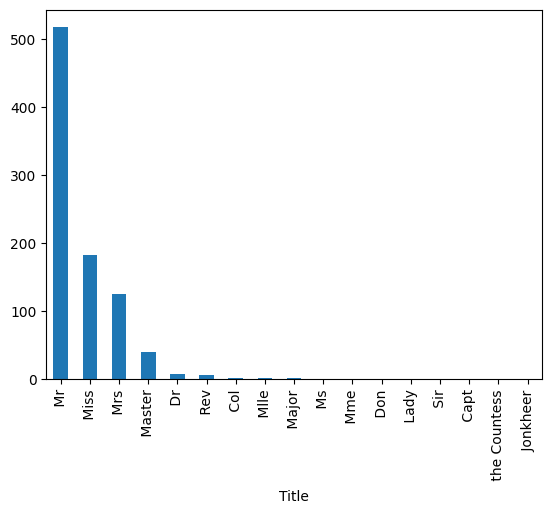

In [61]:
df['Title'].value_counts().plot(kind= 'bar',)